In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [3]:
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [14:37<00:00, 194kB/s]


In [4]:
# Select a fixed image

image_index = 0
x0, label = dataset[image_index]

print("Class label:", dataset.classes[label])

Class label: frog


In [5]:
def add_noise(x, beta):
  noise = torch.randn_like(x)
  return torch.sqrt(1-beta)*x + torch.sqrt(beta)*noise

In [ ]:
# Reverse Process

#Instead of directly predicting original image, it predicts
# epsilon(xt, t)

# Why?
# Predicting noise is easier than predicting image

# U-net backbone
# Time embedding
# Noise Scheduler

In [6]:
betas = [0.01, 0.05, 0.1, 0.3, 0.6]

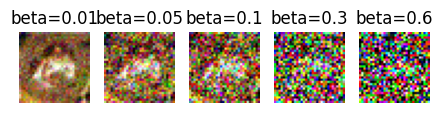

In [7]:
for i,b in enumerate(betas):
  xt = add_noise(x0, torch.tensor(b))
  plt.subplot(1, len(betas)+1, i+2)
  plt.imshow(xt.permute(1,2,0).clamp(0,1))
  plt.title(f"beta={b}")
  plt.axis("off")

plt.show()

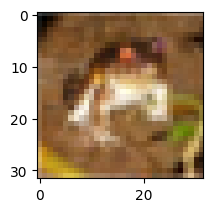

In [8]:
plt.figure(figsize=(15,3))

plt.subplot(1, len(betas)+1, 1)
plt.imshow(x0.permute(1,2,0))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Is available ::  True


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

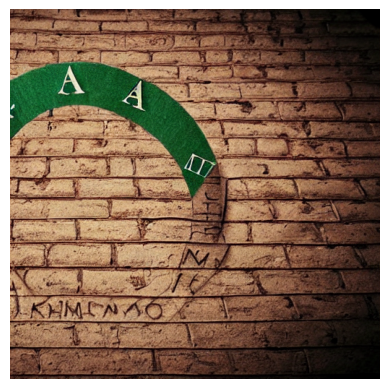

In [9]:
# Apply pretrained diffusion model

from diffusers import StableDiffusionPipeline
import torch
print("Is available :: ",torch.cuda.is_available())
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

prompt = "English alphabet"
image = pipe(prompt).images[0]
plt.imshow(image)
plt.axis("off")
plt.show()
image.save("output.png")

In [10]:
from PIL import Image

img = Image.open("output.png")
img.show()

Is available ::  True


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

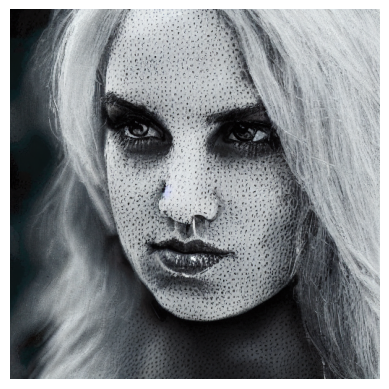

In [19]:
# Image-to-Image Generation


from diffusers import StableDiffusionPipeline
import torch
print("Is available :: ",torch.cuda.is_available())
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

init_image = Image.open("output.png")

prompt = "Can you increase the resolution, sharpen facial features"
image = pipe(prompt=prompt, image=init_image, strength=0.7).images[0]
plt.imshow(image)
plt.axis("off")
plt.show()
image.save("edited_2.png")

# Strength parameter controls how much noise is added
# More noise  ====> more creativity
# Less noise ===> More structure preservation

## Extension Exercise: Understanding Forward Diffusion Over Timesteps

In a full diffusion model, noise isn't added in a single step with a fixed `beta`. Instead, it's a gradual process over many small steps, known as timesteps (`T`), each with its own `beta` value. The collection of `beta` values for each timestep is called the noise schedule.

This exercise will help visualize how an image progressively becomes pure noise as we apply the forward diffusion process over several timesteps, using a simple linear noise schedule.

In [12]:
import numpy as np

# Define the number of timesteps
T = 1000

# Define a linear noise schedule
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)

# Calculate alpha values (1 - beta)
alphas = 1.0 - betas

# Calculate cumulative product of alphas
alpha_cumprod = torch.cumprod(alphas, axis=0)

print(f"Number of timesteps (T): {T}")
print(f"First 5 betas: {betas[:5]}")
print(f"Last 5 betas: {betas[-5:]}")

Number of timesteps (T): 1000
First 5 betas: tensor([1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04])
Last 5 betas: tensor([0.0199, 0.0199, 0.0200, 0.0200, 0.0200])


Now, let's observe the image at a few selected timesteps to see how it gradually transforms into noise. We'll reuse the `add_noise` function, but apply the formula for `x_t` directly, which incorporates the cumulative product of alphas for efficient computation over many steps:

`x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * epsilon`

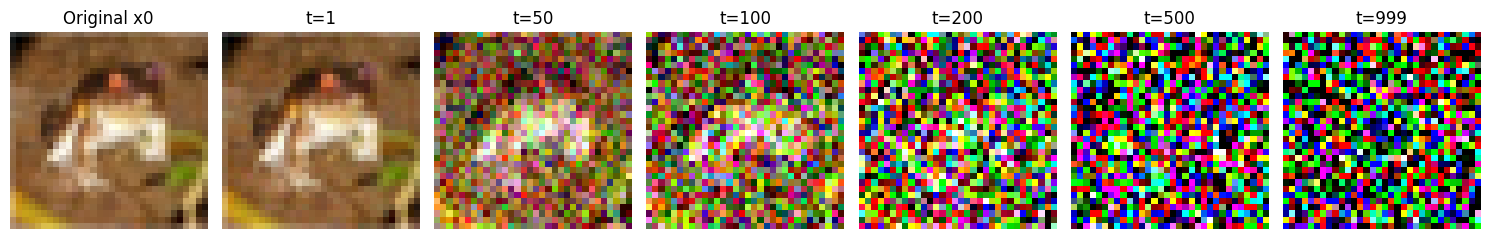

In [13]:
def forward_diffusion_at_t(x0, t, alpha_cumprod):
  """Applies forward diffusion to x0 at a specific timestep t."""
  noise = torch.randn_like(x0)
  sqrt_alpha_cumprod_t = torch.sqrt(alpha_cumprod[t-1]) # t-1 because alpha_cumprod is 0-indexed
  sqrt_one_minus_alpha_cumprod_t = torch.sqrt(1.0 - alpha_cumprod[t-1])
  xt = sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise
  return xt

# Choose a few timesteps to visualize
visualization_timesteps = [1, 50, 100, 200, 500, 999]

plt.figure(figsize=(15, 4))
plt.subplot(1, len(visualization_timesteps) + 1, 1)
plt.imshow(x0.permute(1, 2, 0).clamp(0, 1)) # Original image
plt.title("Original x0")
plt.axis("off")

for i, t in enumerate(visualization_timesteps):
  xt = forward_diffusion_at_t(x0, t, alpha_cumprod)
  plt.subplot(1, len(visualization_timesteps) + 1, i + 2)
  plt.imshow(xt.permute(1, 2, 0).clamp(0, 1))
  plt.title(f"t={t}")
  plt.axis("off")

plt.tight_layout()
plt.show()

As you can see, as the timestep `t` increases, more noise is added, and the original image progressively becomes indistinguishable from pure Gaussian noise. This is the forward process that a diffusion model aims to reverse during denoising.

In [ ]:
# Difference between DDPM vs DDIM
# DDPM = Probabilistic Denoising model (stochastic) 1000 -> 995 -> 985 -> 965 -> 930 ->.....->0
# DDIM = Implicit Denoising model (deterministic) 1000 -> 800 -> 600 -> 400 -> 200 -> ....->0
#Sampling procedure is different

### DDPM vs DDIM

| Feature | DDPM | DDIM |
|----------|----------|----------|
| Full Form | Denoising Diffusion Probabilistic Model | Denoising Diffusion Implicit Model |
| Sampling Type | Stochastic (random) | Deterministic |
| Sampling Steps | ~1000 | 20–100 |
| Inference Speed | Slow | Fast |
| Reverse Process | 1000 → 999 → ... → 0 | 1000 → 800 → 600 → ... → 0 |
| Noise During Sampling | Added at every step | No extra noise |
| Reproducibility | Lower | Higher |
| Image Quality | High | Similar quality with fewer steps |
| Main Advantage | Better theoretical diffusion process | Much faster image generation |

**Summary:** DDPM uses many small denoising steps and includes randomness, while DDIM skips timesteps and uses a deterministic process, resulting in significantly faster image generation with comparable quality.

Helper Function

In [14]:
def sample_xt_from_timestep(x0, timestep, alpha_cumprod):
    """
    Generate x_t directly from x0 using
    the closed-form forward diffusion equation.

    x_t = sqrt(alpha_bar_t) * x0 +
          sqrt(1-alpha_bar_t) * epsilon
    """
    noise = torch.randn_like(x0)

    alpha_bar_t = alpha_cumprod[timestep]

    xt = (
        torch.sqrt(alpha_bar_t) * x0
        + torch.sqrt(1 - alpha_bar_t) * noise
    )

    return xt

DDPM Dense Schedule Visualization

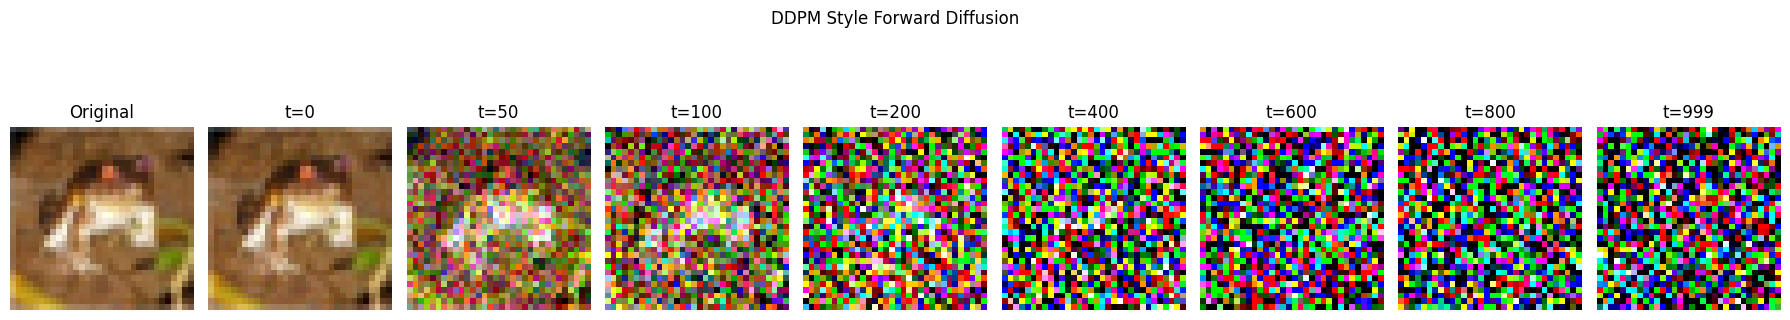

In [15]:
ddpm_steps = [0, 50, 100, 200, 400, 600, 800, 999]

plt.figure(figsize=(18,4))

plt.subplot(1, len(ddpm_steps)+1, 1)
plt.imshow(x0.permute(1,2,0).clamp(0,1))
plt.title("Original")
plt.axis("off")

for idx, t in enumerate(ddpm_steps):

    xt = sample_xt_from_timestep(
        x0,
        t,
        alpha_cumprod
    )

    plt.subplot(1, len(ddpm_steps)+1, idx+2)
    plt.imshow(
        xt.permute(1,2,0).clamp(0,1)
    )
    plt.title(f"t={t}")
    plt.axis("off")

plt.suptitle("DDPM Style Forward Diffusion")
plt.tight_layout()
plt.show()

DDIM Sparse Schedule Visualization

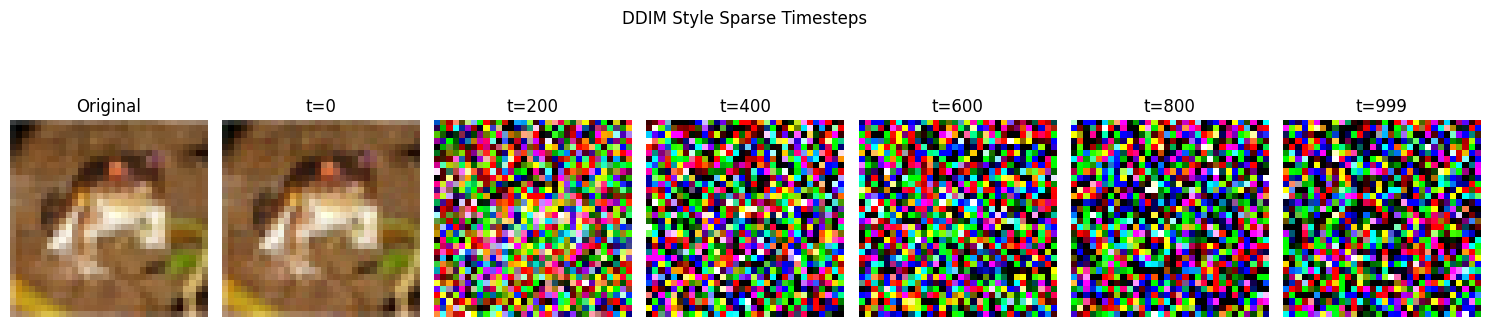

In [16]:
ddim_steps = [0, 200, 400, 600, 800, 999]

plt.figure(figsize=(15,4))

plt.subplot(1, len(ddim_steps)+1, 1)
plt.imshow(x0.permute(1,2,0).clamp(0,1))
plt.title("Original")
plt.axis("off")

for idx, t in enumerate(ddim_steps):

    xt = sample_xt_from_timestep(
        x0,
        t,
        alpha_cumprod
    )

    plt.subplot(1, len(ddim_steps)+1, idx+2)
    plt.imshow(
        xt.permute(1,2,0).clamp(0,1)
    )
    plt.title(f"t={t}")
    plt.axis("off")

plt.suptitle("DDIM Style Sparse Timesteps")
plt.tight_layout()
plt.show()

Side-by-Side DDPM vs DDIM Comparison

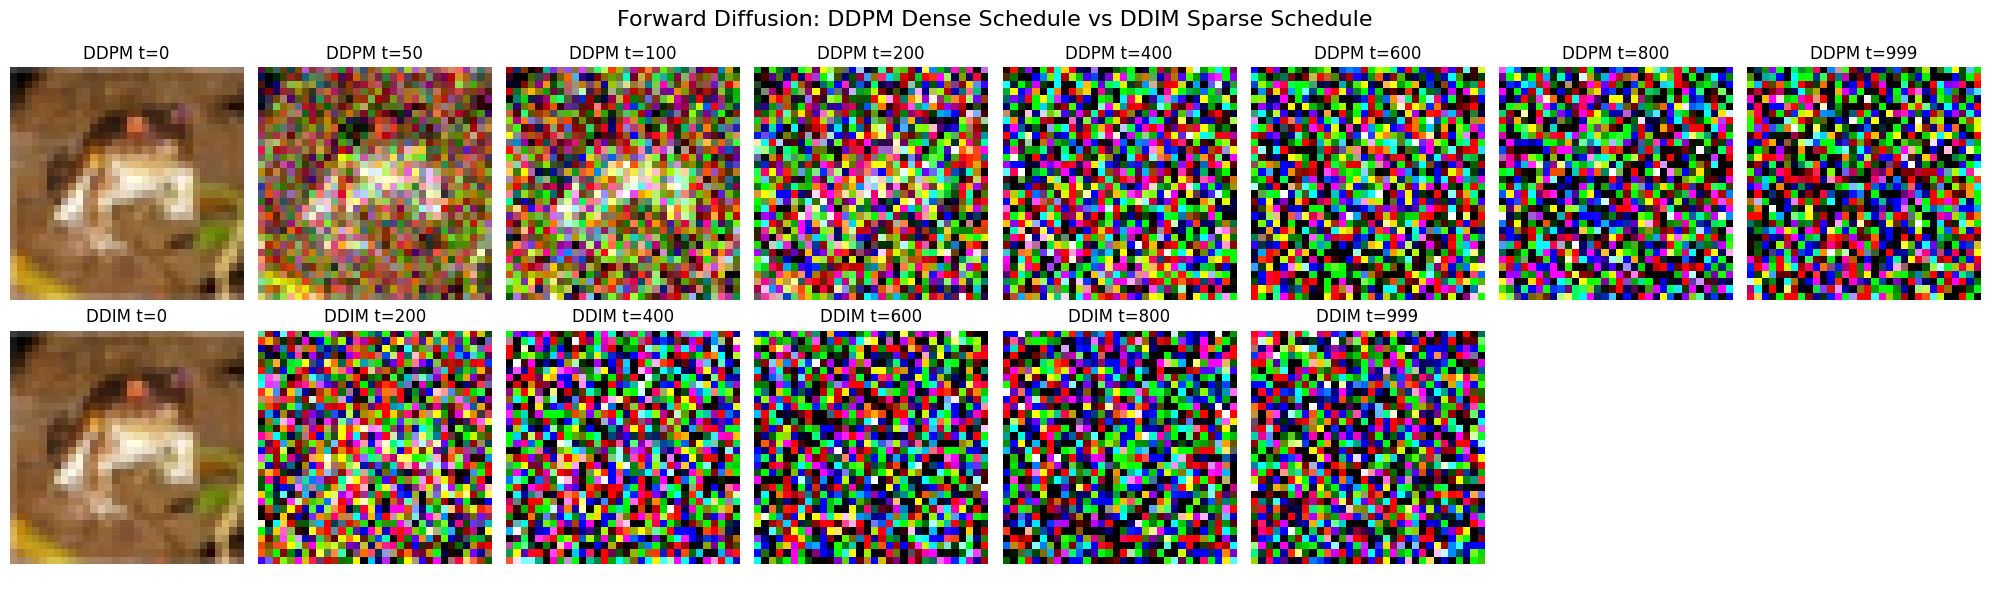

In [17]:
ddpm_steps = [0, 50, 100, 200, 400, 600, 800, 999]
ddim_steps = [0, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(
    2,
    max(len(ddpm_steps), len(ddim_steps)),
    figsize=(20,6)
)

# DDPM Row
for i, t in enumerate(ddpm_steps):

    if t == 0:
        img = x0
    else:
        img = sample_xt_from_timestep(
            x0,
            t,
            alpha_cumprod
        )

    axes[0, i].imshow(
        img.permute(1,2,0).clamp(0,1)
    )
    axes[0, i].set_title(f"DDPM t={t}")
    axes[0, i].axis("off")

# DDIM Row
for i, t in enumerate(ddim_steps):

    if t == 0:
        img = x0
    else:
        img = sample_xt_from_timestep(
            x0,
            t,
            alpha_cumprod
        )

    axes[1, i].imshow(
        img.permute(1,2,0).clamp(0,1)
    )
    axes[1, i].set_title(f"DDIM t={t}")
    axes[1, i].axis("off")

# Hide unused subplot cells
for j in range(len(ddim_steps), len(ddpm_steps)):
    axes[1, j].axis("off")

plt.suptitle(
    "Forward Diffusion: DDPM Dense Schedule vs DDIM Sparse Schedule",
    fontsize=16
)

plt.tight_layout()
plt.show()

Noise Percentage Analysis

In [18]:
selected_steps = [0, 50, 100, 200, 400, 600, 800, 999]

print("Timestep Analysis")
print("-" * 50)

for t in selected_steps:

    alpha_bar = alpha_cumprod[t].item()

    signal_percent = alpha_bar * 100
    noise_percent = (1 - alpha_bar) * 100

    print(
        f"t={t:4d} | "
        f"Signal={signal_percent:6.2f}% | "
        f"Noise={noise_percent:6.2f}%"
    )

Timestep Analysis
--------------------------------------------------
t=   0 | Signal= 99.99% | Noise=  0.01%
t=  50 | Signal= 97.00% | Noise=  3.00%
t= 100 | Signal= 89.51% | Noise= 10.49%
t= 200 | Signal= 65.63% | Noise= 34.37%
t= 400 | Signal= 19.36% | Noise= 80.64%
t= 600 | Signal=  2.56% | Noise= 97.44%
t= 800 | Signal=  0.15% | Noise= 99.85%
t= 999 | Signal=  0.00% | Noise=100.00%
